<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


       MIN-MAX USING DIVIDE AND CONQUER
Array : [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
Min   : 0
Max   : 9
D&C Comparisons    : 14
Naive Comparisons  : 18

          PERFORMANCE ANALYSIS
      Size       DC Comps      Naive Comps      Formula 3n/2-2
--------------------------------------------------------------
        10             14               18                  13
       100            162              198                 148
      1000           1510             1998                1498
     10000          15902            19998               14998


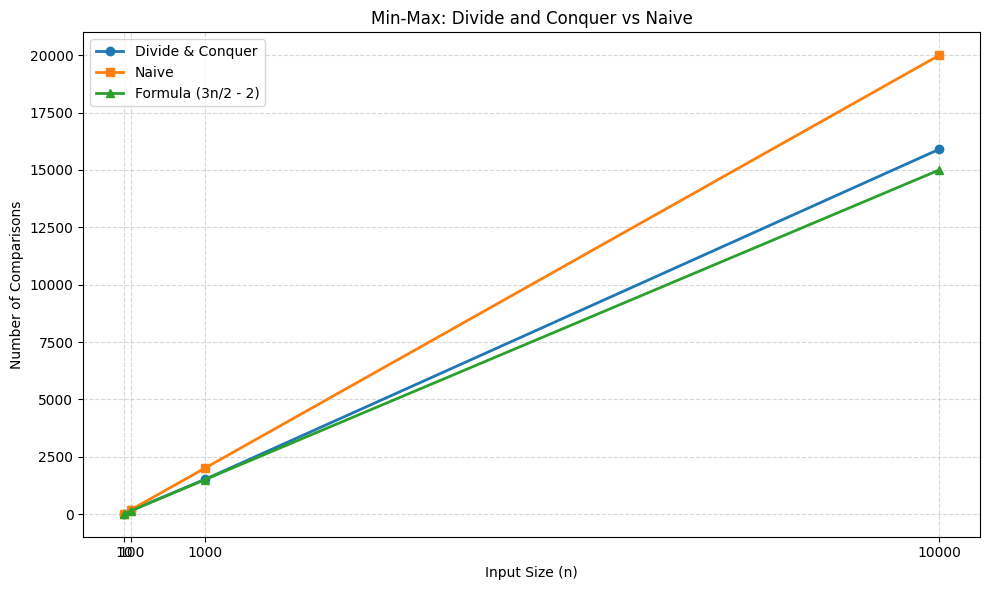

In [1]:
import random
import matplotlib.pyplot as plt


# ==========================================
# DIVIDE AND CONQUER MIN-MAX
# ==========================================

comparison_count = 0


def min_max_dc(arr, low, high):

    global comparison_count

    # Base case: single element
    if low == high:
        return arr[low], arr[low]

    # Base case: two elements
    if high == low + 1:

        comparison_count += 1

        if arr[low] < arr[high]:
            return arr[low], arr[high]

        return arr[high], arr[low]

    # Divide
    mid = (low + high) // 2

    lmin, lmax = min_max_dc(arr, low, mid)
    rmin, rmax = min_max_dc(arr, mid + 1, high)

    # Conquer - compare minimum values
    comparison_count += 1

    if lmin < rmin:
        overall_min = lmin
    else:
        overall_min = rmin

    # Conquer - compare maximum values
    comparison_count += 1

    if lmax > rmax:
        overall_max = lmax
    else:
        overall_max = rmax

    return overall_min, overall_max


# ==========================================
# NAIVE MIN-MAX
# ==========================================

def min_max_naive(arr):

    mn = arr[0]
    mx = arr[0]

    comps = 0

    for x in arr[1:]:

        comps += 1

        if x < mn:
            mn = x

        comps += 1

        if x > mx:
            mx = x

    return mn, mx, comps


# ==========================================
# DEMONSTRATION
# ==========================================

arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]

comparison_count = 0

mn, mx = min_max_dc(
    arr,
    0,
    len(arr) - 1
)

dc_comps = comparison_count

_, _, naive_comps = min_max_naive(arr)


print("\n==============================================")
print("       MIN-MAX USING DIVIDE AND CONQUER")
print("==============================================")

print("Array :", arr)
print("Min   :", mn)
print("Max   :", mx)

print("D&C Comparisons    :", dc_comps)
print("Naive Comparisons  :", naive_comps)


# ==========================================
# PERFORMANCE ANALYSIS
# ==========================================

sizes = [10, 100, 1000, 10000]

dc_results = []
naive_results = []
formula_results = []


print("\n==============================================")
print("          PERFORMANCE ANALYSIS")
print("==============================================")

print(
    f"{'Size':>10}"
    f"{'DC Comps':>15}"
    f"{'Naive Comps':>17}"
    f"{'Formula 3n/2-2':>20}"
)

print("-" * 62)


for size in sizes:

    arr = [
        random.randint(1, 10000)
        for _ in range(size)
    ]

    # Divide and Conquer
    comparison_count = 0

    mn, mx = min_max_dc(
        arr,
        0,
        len(arr) - 1
    )

    dc = comparison_count

    # Naive
    _, _, naive = min_max_naive(arr)

    # Theoretical formula
    formula = (3 * size) // 2 - 2

    # Store results for graph
    dc_results.append(dc)
    naive_results.append(naive)
    formula_results.append(formula)

    print(
        f"{size:>10}"
        f"{dc:>15}"
        f"{naive:>17}"
        f"{formula:>20}"
    )


# ==========================================
# GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    dc_results,
    marker="o",
    linewidth=2,
    label="Divide & Conquer"
)

plt.plot(
    sizes,
    naive_results,
    marker="s",
    linewidth=2,
    label="Naive"
)

plt.plot(
    sizes,
    formula_results,
    marker="^",
    linewidth=2,
    label="Formula (3n/2 - 2)"
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")

plt.title(
    "Min-Max: Divide and Conquer vs Naive"
)

plt.xticks(sizes)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()